[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/03-classical-ml/06_trees_random_forests.ipynb)

# Splits, Variance, and an Importance That Lies

**Session 13 · no homework grades this · the project will use it**

A decision tree is the one model in this course you can compute by hand, so this
notebook starts by doing exactly that — one split, with the arithmetic on the
page — and then spends the rest of its time on the two things that go wrong
afterwards: a single tree's variance, and the feature importance that everybody
reads and almost nobody checks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(31)

## 1. One split, by hand

Gini impurity of a node is `1 - sum(p_k^2)`. A split is scored by the weighted
impurity of its children, and the best split is the one that lowers it most.

Nine rows, one feature, two classes:

In [2]:
feature = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
label = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])

def gini(values):
    if len(values) == 0:
        return 0.0
    p = np.bincount(values, minlength=2) / len(values)
    return 1 - (p ** 2).sum()

parent = gini(label)
print(f"parent impurity: {parent:.4f}  (class counts {np.bincount(label)})\n")
print(f"{'threshold':>9} {'left':>18} {'right':>18} {'weighted':>10} {'gain':>8}")
for t in (feature[:-1] + feature[1:]) / 2:
    left, right = label[feature <= t], label[feature > t]
    weighted = (len(left) * gini(left) + len(right) * gini(right)) / len(label)
    print(f"{t:>9.2f} {str(np.bincount(left, minlength=2)):>10} {gini(left):>7.4f}"
          f" {str(np.bincount(right, minlength=2)):>10} {gini(right):>7.4f}"
          f" {weighted:>10.4f} {parent - weighted:>8.4f}")

parent impurity: 0.4938  (class counts [4 5])

threshold               left              right   weighted     gain
     1.25      [1 0]  0.0000      [3 5]  0.4688     0.4167   0.0772
     1.75      [2 0]  0.0000      [2 5]  0.4082     0.3175   0.1764
     2.25      [3 0]  0.0000      [1 5]  0.2778     0.1852   0.3086
     2.75      [3 1]  0.3750      [1 4]  0.3200     0.3444   0.1494
     3.25      [4 1]  0.3200      [0 4]  0.0000     0.1778   0.3160
     3.75      [4 2]  0.4444      [0 3]  0.0000     0.2963   0.1975
     4.25      [4 3]  0.4898      [0 2]  0.0000     0.3810   0.1129
     4.75      [4 4]  0.5000      [0 1]  0.0000     0.4444   0.0494


The best threshold is the row with the largest gain, and scikit-learn does
exactly this, for every feature, at every node. Nothing is hidden — which is
why a tree is the model you can always explain to a stakeholder, and why its
failure mode is so easy to miss.

Confirm against the library:

In [3]:
from sklearn.tree import DecisionTreeClassifier, export_text

stump = DecisionTreeClassifier(max_depth=1).fit(feature.reshape(-1, 1), label)
print(export_text(stump, feature_names=["x"]))

|--- x <= 3.25
|   |--- class: 0
|--- x >  3.25
|   |--- class: 1



## 2. The fatal flaw: variance

A tree is fitted by a sequence of greedy choices, and a greedy choice can flip
on one row. Below: the same data, resampled, fitted eleven times.

In [4]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=1200, n_features=8, n_informative=5,
                           class_sep=0.9, random_state=31)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)

first_features, depths, scores = [], [], []
for seed in range(11):
    idx = np.random.default_rng(seed).choice(len(X_train), len(X_train), replace=True)
    tree = DecisionTreeClassifier(random_state=0).fit(X_train[idx], y_train[idx])
    first_features.append(int(tree.tree_.feature[0]))
    depths.append(tree.get_depth())
    scores.append(tree.score(X_test, y_test))

print("root feature chosen on each bootstrap:", first_features)
print("tree depth                           :", depths)
print(f"test accuracy: mean {np.mean(scores):.3f}, "
      f"range {min(scores):.3f} to {max(scores):.3f}")

predictions = []
for seed in range(11):
    idx = np.random.default_rng(seed).choice(len(X_train), len(X_train), replace=True)
    predictions.append(DecisionTreeClassifier(random_state=0)
                       .fit(X_train[idx], y_train[idx]).predict(X_test))
predictions = np.array(predictions)
print(f"\ntest rows where all eleven trees agree: "
      f"{(predictions == predictions[0]).all(axis=0).mean():.1%}")

root feature chosen on each bootstrap: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
tree depth                           : [12, 12, 11, 12, 12, 12, 10, 14, 12, 11, 12]
test accuracy: mean 0.895, range 0.867 to 0.913

test rows where all eleven trees agree: 68.7%


Here the root feature is the same every time — the strongest signal in this
dataset survives resampling. Everything below it does not: the depth moves, test
accuracy swings several points, and the eleven trees disagree outright about a
noticeable share of test rows.

That spread is *variance* in the precise sense of Session 9 — the same procedure,
run on samples from the same source, produces different models — and it is the
reason a forest exists.

## 3. Pruning: capacity, controlled after the fact

`max_depth` prunes before growing. `ccp_alpha` prunes after: grow the tree out,
then remove the subtrees whose contribution does not justify their complexity.

In [5]:
full = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
path = full.cost_complexity_pruning_path(X_train, y_train)

rows = []
for alpha in path.ccp_alphas[::max(1, len(path.ccp_alphas) // 12)]:
    t = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha).fit(X_train, y_train)
    rows.append({"ccp_alpha": round(float(alpha), 5), "leaves": t.get_n_leaves(),
                 "depth": t.get_depth(), "train": round(t.score(X_train, y_train), 3),
                 "test": round(t.score(X_test, y_test), 3)})
print(pd.DataFrame(rows).to_string(index=False))

 ccp_alpha  leaves  depth  train  test
   0.00000      69     13  1.000 0.917
   0.00107      61     13  0.996 0.923
   0.00109      55     13  0.992 0.927
   0.00146      48     13  0.987 0.927
   0.00178      44     13  0.982 0.927
   0.00190      41     13  0.979 0.927
   0.00205      38     13  0.976 0.927
   0.00214      32     13  0.969 0.923
   0.00263      24      8  0.956 0.933
   0.00323      20      8  0.948 0.933
   0.00391      17      7  0.942 0.933
   0.00581      14      7  0.931 0.917
   0.00973      11      6  0.909 0.913
   0.01231       6      3  0.881 0.897
   0.06391       2      1  0.781 0.773


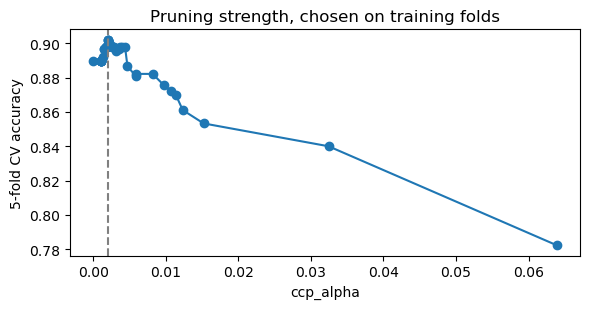

alpha 0.00199: 40 leaves, depth 13
unpruned: 69 leaves, depth 13


In [6]:
from sklearn.model_selection import cross_val_score

alphas = path.ccp_alphas[:-1]
cv_means = [cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a),
                            X_train, y_train, cv=5).mean()
            for a in alphas[::max(1, len(alphas) // 25)]]
sampled = alphas[::max(1, len(alphas) // 25)]
best_alpha = float(sampled[int(np.argmax(cv_means))])

plt.figure(figsize=(6, 3.2))
plt.plot(sampled, cv_means, "o-")
plt.axvline(best_alpha, ls="--", color="grey")
plt.xlabel("ccp_alpha"); plt.ylabel("5-fold CV accuracy")
plt.title("Pruning strength, chosen on training folds")
plt.tight_layout(); plt.show()

pruned = DecisionTreeClassifier(random_state=0, ccp_alpha=best_alpha).fit(X_train, y_train)
print(f"alpha {best_alpha:.5f}: {pruned.get_n_leaves()} leaves, depth {pruned.get_depth()}")
print(f"unpruned: {full.get_n_leaves()} leaves, depth {full.get_depth()}")

## 4. A forest: the same variance, averaged away

In [7]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=300, oob_score=True,
                                random_state=0, n_jobs=-1).fit(X_train, y_train)

print(f"single tree, unpruned : test {full.score(X_test, y_test):.4f}")
print(f"single tree, pruned   : test {pruned.score(X_test, y_test):.4f}")
print(f"forest of 300         : test {forest.score(X_test, y_test):.4f}")
print(f"\nout-of-bag estimate   : {forest.oob_score_:.4f}")
print(f"held-out test         : {forest.score(X_test, y_test):.4f}")
print(f"difference            : {abs(forest.oob_score_ - forest.score(X_test, y_test)):.4f}")

single tree, unpruned : test 0.9167
single tree, pruned   : test 0.9267
forest of 300         : test 0.9567

out-of-bag estimate   : 0.9333
held-out test         : 0.9567
difference            : 0.0233


The out-of-bag score is nearly free: each tree is fitted on a bootstrap sample,
so roughly a third of the rows are unused by any given tree and can score it.
It lands close to the held-out number here, which is the usual case — and it is
still not a substitute for a test set, because every OOB row has influenced the
forest through the other trees that did see it.

Use OOB as a fast during-development signal. Report the test set.

## 5. The importance that lies

Impurity importance is biased toward features that offer many places to split,
so a demonstration needs columns that differ in cardinality: four binary
predictors, two three-level ones, and one continuous column of pure noise with a
different value in every row.

Three of the binary columns genuinely drive the label. The continuous one drives
nothing at all.

In [8]:
n = 1500
binary = rng.integers(0, 2, (n, 4)).astype(float)
levels = rng.integers(0, 3, (n, 2)).astype(float)
noise_id = rng.normal(size=n)                       # continuous: every value unique

signal = (1.6 * binary[:, 0] + 1.2 * binary[:, 1] + 0.9 * (levels[:, 0] == 2)
          - 1.1 * binary[:, 2] + rng.normal(0, 0.6, n))
target = (signal > np.median(signal)).astype(int)

table = np.column_stack([binary, levels, noise_id])
names = [f"binary_{i}" for i in range(4)] + ["level_0", "level_1", "noise_id"]

T_train, T_test, t_train, t_test = train_test_split(
    table, target, test_size=0.25, random_state=0, stratify=target)

print("distinct values per column, in training:")
for name, col in zip(names, T_train.T):
    print(f"  {name:<10} {len(np.unique(col)):>5}")

distinct values per column, in training:
  binary_0       2
  binary_1       2
  binary_2       2
  binary_3       2
  level_0        3
  level_1        3
  noise_id    1125


In [9]:
forest_id = RandomForestClassifier(n_estimators=300, random_state=0,
                                   n_jobs=-1).fit(T_train, t_train)
print(f"test accuracy: {forest_id.score(T_test, t_test):.3f}\n")

impurity = pd.Series(forest_id.feature_importances_, index=names).sort_values(ascending=False)
print("impurity ('gini') importance, from the TRAINING fit:")
print(impurity.round(4).to_string())
print(f"\nnoise_id ranks {list(impurity.index).index('noise_id') + 1} of {len(names)}")

test accuracy: 0.821

impurity ('gini') importance, from the TRAINING fit:
binary_0    0.3157
noise_id    0.3012
binary_1    0.1465
binary_2    0.0955
level_0     0.0771
level_1     0.0415
binary_3    0.0224

noise_id ranks 2 of 7


A column correlated with nothing takes **thirty percent of the credit** — second
place, ahead of every genuinely predictive column except one, and more than the
three real ones below it combined.

This is not a bug and not this dataset. Impurity importance credits a feature for
the impurity its splits removed, and a continuous column with more than a
thousand distinct values offers more than a thousand candidate thresholds at
every node. Some of them fit the training noise, and every one of those splits is
credited. A binary column offers exactly one threshold, and cannot compete for
that credit no matter how real it is.

Permutation importance asks a different question — *how much worse does the model
get on data it has never seen, if I shuffle this column?* — and it asks it where
the answer means something.

In [10]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(forest_id, T_test, t_test, n_repeats=20,
                              random_state=0, n_jobs=-1)
print("permutation importance, on the HELD-OUT rows:")
for i in np.argsort(perm.importances_mean)[::-1]:
    print(f"  {names[i]:<10} {perm.importances_mean[i]:>8.4f}  +/- {perm.importances_std[i]:.4f}")

permutation importance, on the HELD-OUT rows:
  binary_0     0.2035  +/- 0.0173
  binary_1     0.1071  +/- 0.0129
  binary_2     0.0871  +/- 0.0139
  level_0      0.0515  +/- 0.0142
  noise_id     0.0041  +/- 0.0108
  binary_3    -0.0029  +/- 0.0068
  level_1     -0.0065  +/- 0.0129


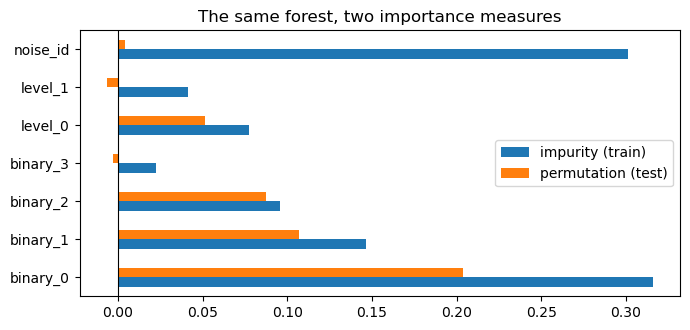

In [11]:
compare = pd.DataFrame({"impurity (train)": forest_id.feature_importances_,
                        "permutation (test)": perm.importances_mean}, index=names)
fig, ax = plt.subplots(figsize=(7, 3.4))
compare.plot.barh(ax=ax)
ax.axvline(0, color="black", lw=.8)
ax.set_title("The same forest, two importance measures")
plt.tight_layout(); plt.show()

`noise_id` drops from second place to fifth, at 0.004 — smaller than its own
standard deviation, which is the honest way of saying zero. Shuffling it does not
move the score on rows the forest has never seen, because on those rows it never
helped. The binary columns that actually generate the label come out on top,
roughly in the order of their coefficients, and the two columns that generate
nothing (`binary_3`, `level_1`) sit slightly below zero, where they belong.

Three limits on permutation importance, all worth saying to whoever asks you for
"the important features":

1. It is **relative to a fitted model, a dataset and a metric.** Refit the model
   and the numbers move.
2. It is **not causal.** It says the model's predictions depend on this column,
   not that the column drives the outcome in the world.
3. It **splits credit badly among correlated features.** If two columns carry the
   same information, shuffling either alone changes little and both look
   unimportant. Check correlations before believing a zero.

## What to take from this

- A split is arithmetic you can do by hand; nothing about a tree is mysterious.
- A single tree's structure is unstable under resampling. That variance is what
  a forest averages away.
- `ccp_alpha` prunes after growing, and its value is chosen on training folds.
- OOB is a cheap development estimate, not a test set.
- Impurity importance favours high-cardinality features. Prefer permutation
  importance on held-out data, and read even that as a statement about the
  model rather than about the world.

## Where to go next

- **Reading, Session 13** — impurity arithmetic, pruning, and importances.
- **Session 14** — boosting, where the trees stop being independent.